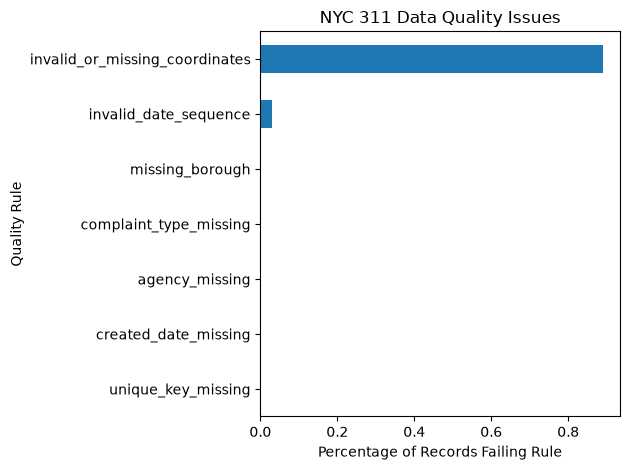

In [37]:
quality_report.sort_values(
    "failure_percentage"
).plot(
    x="rule",
    y="failure_percentage",
    kind="barh",
    legend=False,
)

plt.title("NYC 311 Data Quality Issues")
plt.xlabel("Percentage of Records Failing Rule")
plt.ylabel("Quality Rule")
plt.tight_layout()
plt.show()

In [36]:
quality_report = pd.read_csv(
    QUALITY_FILE
)

quality_report

,rule,failure_count,total_rows,failure_percentage
0,unique_key_missing,0,348180,0.00
1,created_date_missing,0,348180,0.00
2,agency_missing,0,348180,0.00
3,complaint_type_missing,0,348180,0.00
4,invalid_date_sequence,97,348180,0.03
5,missing_borough,0,348180,0.00
6,invalid_or_missing_coordinates,3105,348180,0.89


In [35]:
QUALITY_FILE = (
    project_root
    / "reports"
    / "data_quality_report.csv"
)

print("Quality report exists:", QUALITY_FILE.exists())

Quality report exists: True


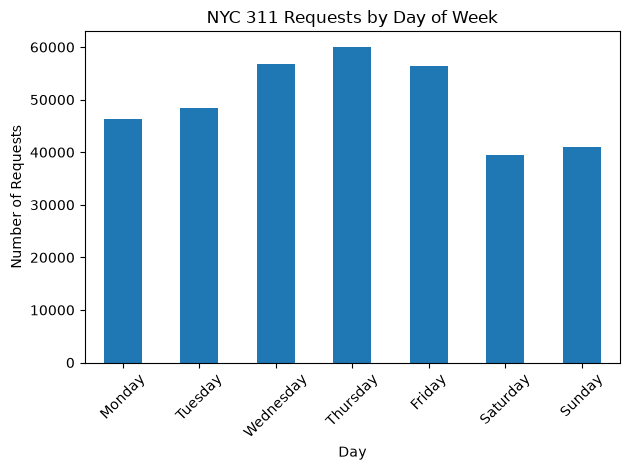

In [34]:
requests_by_day.plot(
    x="day",
    y="request_count",
    kind="bar",
    legend=False,
)

plt.title("NYC 311 Requests by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

requests_by_day = (
    df["created_day_name"]
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

requests_by_day.columns = [
    "day",
    "request_count",
]

requests_by_day

,day,request_count
0,Monday,46269
1,Tuesday,48368
2,Wednesday,56781
3,Thursday,59993
4,Friday,56444
5,Saturday,39407
6,Sunday,40918


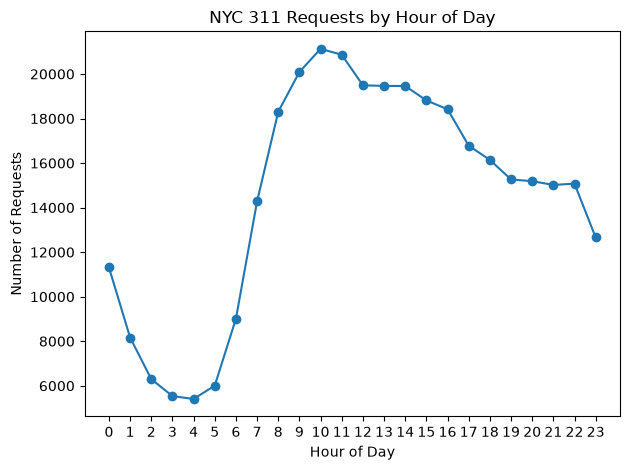

In [32]:
requests_by_hour.plot(
    x="created_hour",
    y="request_count",
    kind="line",
    marker="o",
    legend=False,
)

plt.title("NYC 311 Requests by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [31]:
requests_by_hour = (
    df.groupby("created_hour")
    .size()
    .reset_index(name="request_count")
)

requests_by_hour

,created_hour,request_count
0,0,11313
1,1,8165
2,2,6299
3,3,5537
4,4,5406
5,5,6005
6,6,9009
7,7,14281
8,8,18304
9,9,20090


In [30]:
agency_resolution = (
    df.loc[
        df["resolution_hours"].notna()
        & (df["resolution_hours"] >= 0)
    ]
    .groupby("agency")
    .agg(
        closed_requests=(
            "unique_key",
            "count",
        ),
        median_resolution_hours=(
            "resolution_hours",
            "median",
        ),
        average_resolution_hours=(
            "resolution_hours",
            "mean",
        ),
    )
    .query("closed_requests >= 100")
    .sort_values(
        "median_resolution_hours"
    )
)

agency_resolution

,closed_requests,median_resolution_hours,average_resolution_hours
agency,,,
NYPD,153175,2.076667,4.925720
DHS,1138,12.082083,687.616668
DEP,15140,21.400000,112.275564
DOT,16224,29.601944,241.163051
DSNY,26253,32.210556,93.910033
DOHMH,5973,41.535833,522.615870
HPD,110437,65.969444,395.799563
DCWP,1342,84.079167,314.095310
DPR,3537,142.770000,962.472485


In [28]:
valid_resolution_times = df.loc[
    df["resolution_hours"].notna()
    & (df["resolution_hours"] >= 0),
    "resolution_hours",
]

print(
    "Average resolution hours:",
    round(valid_resolution_times.mean(), 2),
)

print(
    "Median resolution hours:",
    round(valid_resolution_times.median(), 2),
)

Average resolution hours: 236.34
Median resolution hours: 15.08


In [27]:
df[
    [
        "created_date",
        "closed_date",
        "resolution_hours",
    ]
].head(10)

,created_date,closed_date,resolution_hours
0,2025-01-01 00:51:02,2025-03-02 00:51:37,1440.009722
1,2025-01-01 00:54:26,2025-01-01 01:47:36,0.886111
2,2025-01-01 01:14:30,2025-01-01 04:38:47,3.404722
3,2025-01-01 01:20:52,2025-01-01 02:21:14,1.006111
4,2025-01-01 01:12:27,2025-01-01 04:37:23,3.415556
5,2025-01-01 00:07:36,2025-01-01 01:33:12,1.426667
6,2025-01-01 00:19:00,2025-01-01 00:19:00,0.000000
7,2025-01-01 00:11:45,2025-01-01 01:21:57,1.170000
8,2025-01-01 00:14:54,2025-01-01 01:19:02,1.068889
9,2025-01-01 00:17:41,2025-01-01 00:30:38,0.215833


### Agency Request Volume

Agency request volume reflects the responsibilities assigned to each
agency and the types of services residents request.

An agency receiving more requests is not necessarily performing poorly.
For that reason, request volume should be treated as a workload measure
rather than a performance ranking.

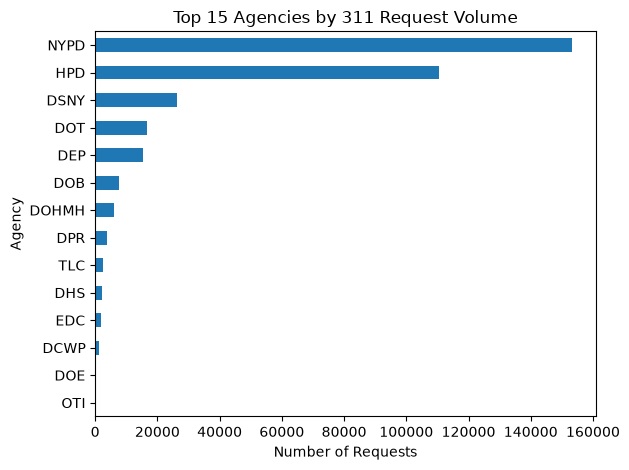

In [26]:
requests_by_agency.sort_values(
    "request_count"
).plot(
    x="agency",
    y="request_count",
    kind="barh",
    legend=False,
)

plt.title("Top 15 Agencies by 311 Request Volume")
plt.xlabel("Number of Requests")
plt.ylabel("Agency")
plt.tight_layout()
plt.show()

In [25]:
requests_by_agency = (
    df["agency"]
    .value_counts()
    .head(15)
    .rename_axis("agency")
    .reset_index(name="request_count")
)

requests_by_agency

,agency,request_count
0,NYPD,153175
1,HPD,110624
2,DSNY,26370
3,DOT,16592
4,DEP,15358
5,DOB,7621
6,DOHMH,6181
7,DPR,3940
8,TLC,2672
9,DHS,2188


### Most Common Problem Types

The chart identifies the most frequently recorded 311 problem categories
during the selected period.

This analysis measures the number of recorded requests, not necessarily
the number of unique physical problems. Multiple residents could report
the same underlying issue.

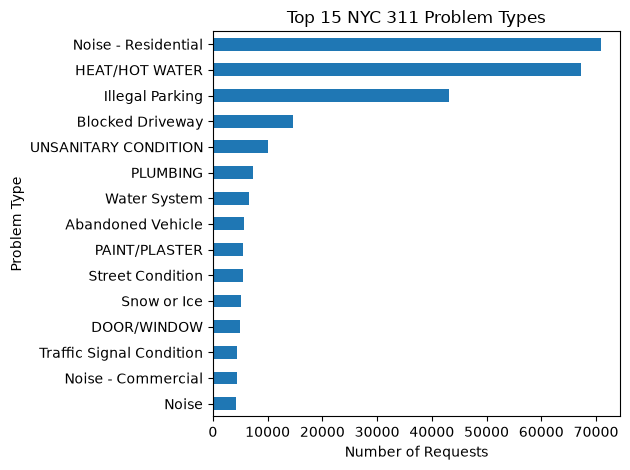

In [24]:
top_problems.sort_values(
    "request_count"
).plot(
    x="problem",
    y="request_count",
    kind="barh",
    legend=False,
)

plt.title("Top 15 NYC 311 Problem Types")
plt.xlabel("Number of Requests")
plt.ylabel("Problem Type")
plt.tight_layout()
plt.show()

In [23]:
top_problems = (
    df["complaint_type"]
    .value_counts()
    .head(15)
    .rename_axis("problem")
    .reset_index(name="request_count")
)

top_problems

,problem,request_count
0,Noise - Residential,70837
1,HEAT/HOT WATER,67229
2,Illegal Parking,43139
3,Blocked Driveway,14661
4,UNSANITARY CONDITION,10000
5,PLUMBING,7409
6,Water System,6671
7,Abandoned Vehicle,5626
8,PAINT/PLASTER,5588
9,Street Condition,5474


### Borough Analysis

This chart compares the number of recorded NYC 311 requests across the
five boroughs during the selected period.

Higher request volume should not automatically be interpreted as poorer
city services or worse neighborhood conditions. Differences in population,
population density, reporting behavior, and the types of requests handled
can affect the number of recorded complaints.

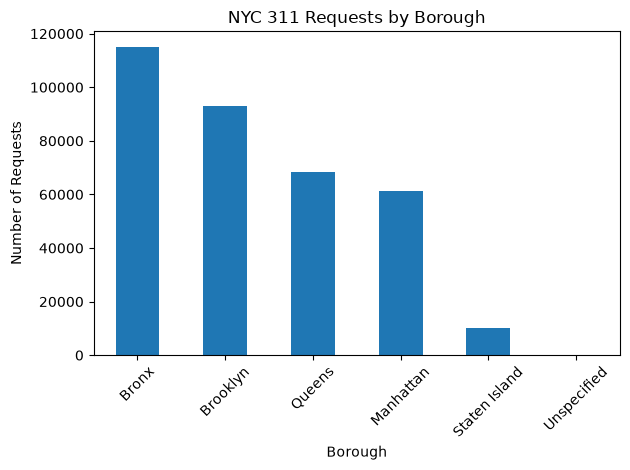

In [22]:
requests_by_borough.plot(
    x="borough",
    y="request_count",
    kind="bar",
    legend=False,
)

plt.title("NYC 311 Requests by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
requests_by_borough = (
    df["borough"]
    .value_counts(dropna=False)
    .rename_axis("borough")
    .reset_index(name="request_count")
)

requests_by_borough

,borough,request_count
0,Bronx,115111
1,Brooklyn,92911
2,Queens,68525
3,Manhattan,61331
4,Staten Island,10125
5,Unspecified,177


## Initial Data Inspection

The cleaned January 2025 NYC 311 dataset contains service-request
records with information about the responding agency, complaint type,
request status, geographic location, creation time, and closure time.

The initial inspection shows that some fields contain missing values.
A missing closure date does not automatically represent bad data because
some requests may still have been open when the dataset was retrieved.

In [11]:
missing_values = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_percentage": (
            df.isna().mean() * 100
        ).round(2),
    }
)

missing_values = missing_values.sort_values(
    "missing_percentage",
    ascending=False,
)

missing_values

,missing_count,missing_percentage
sla_met,346885,99.63
due_date,346867,99.62
location_type,34259,9.84
city,9274,2.66
council_district,4350,1.25
latitude,3105,0.89
longitude,3105,0.89
resolution_hours,2725,0.78
resolution_days,2725,0.78
closed_date,2628,0.75


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348180 entries, 0 to 348179
Data columns (total 38 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   unique_key                      348180 non-null  string        
 1   created_date                    348180 non-null  datetime64[us]
 2   closed_date                     345552 non-null  datetime64[us]
 3   agency                          348180 non-null  string        
 4   agency_name                     348180 non-null  string        
 5   complaint_type                  348180 non-null  string        
 6   descriptor                      346641 non-null  string        
 7   location_type                   313921 non-null  string        
 8   incident_zip                    345845 non-null  string        
 9   city                            338906 non-null  string        
 10  status                          348180 non-null  string        
 11

In [13]:
df.columns.tolist()

['unique_key',
 'created_date',
 'closed_date',
 'agency',
 'agency_name',
 'complaint_type',
 'descriptor',
 'location_type',
 'incident_zip',
 'city',
 'status',
 'due_date',
 'resolution_action_updated_date',
 'community_board',
 'council_district',
 'police_precinct',
 'borough',
 'open_data_channel_type',
 'latitude',
 'longitude',
 'valid_latitude',
 'valid_longitude',
 'has_valid_coordinates',
 'valid_zip_format',
 'borough_raw',
 'status_raw',
 'created_year',
 'created_month_number',
 'created_month_name',
 'created_day_name',
 'created_hour',
 'created_date_only',
 'is_closed',
 'invalid_date_sequence',
 'resolution_hours',
 'resolution_days',
 'sla_evaluable',
 'sla_met']

In [14]:
df.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,city,...,created_month_name,created_day_name,created_hour,created_date_only,is_closed,invalid_date_sequence,resolution_hours,resolution_days,sla_evaluable,sla_met
0,63572086,2025-01-01 00:51:02,2025-03-02 00:51:37,DOHMH,Department of Health and Mental Hygiene,Smoking or Vaping,Allowed in Smoke Free Area,Residential Building,10475,BRONX,...,January,Wednesday,0,2025-01-01,True,False,1440.009722,60.000405,False,<NA>
1,63572092,2025-01-01 00:54:26,2025-01-01 01:47:36,NYPD,New York City Police Department,Illegal Parking,Parking Permit Improper Use,Street/Sidewalk,11373,ELMHURST,...,January,Wednesday,0,2025-01-01,True,False,0.886111,0.036921,False,<NA>
2,63572113,2025-01-01 01:14:30,2025-01-01 04:38:47,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11208,BROOKLYN,...,January,Wednesday,1,2025-01-01,True,False,3.404722,0.141863,False,<NA>
3,63572115,2025-01-01 01:20:52,2025-01-01 02:21:14,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11420,SOUTH OZONE PARK,...,January,Wednesday,1,2025-01-01,True,False,1.006111,0.041921,False,<NA>
4,63572131,2025-01-01 01:12:27,2025-01-01 04:37:23,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11207,BROOKLYN,...,January,Wednesday,1,2025-01-01,True,False,3.415556,0.142315,False,<NA>


In [15]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 348180
Columns: 38


In [16]:
df = pd.read_parquet(DATA_FILE)

print("Data loaded successfully!")

Data loaded successfully!


In [17]:
DATA_FILE = (
    project_root
    / "data"
    / "processed"
    / "nyc_311_2025_01_clean.parquet"
)

print(DATA_FILE)
print("File exists:", DATA_FILE.exists())

c:\Users\NihalGoli\Documents\GitHub\nyc-311-data-quality-pipeline\data\processed\nyc_311_2025_01_clean.parquet
File exists: True


In [18]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

print("Project root:", project_root)

Project root: c:\Users\NihalGoli\Documents\GitHub\nyc-311-data-quality-pipeline


In [19]:
print(Path.cwd())

c:\Users\NihalGoli\Documents\GitHub\nyc-311-data-quality-pipeline\notebooks


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd